**Lab2-DL: A6-MNIST-CNN.ipynb** (BMED365) | Priority: 1 (core)

_MNIST classification with Convolutional Neural Network (CNN) – state-of-the-art_

[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/A6-MNIST-CNN.ipynb)

Last updated: 2025-12-22, 2026-01-15 A. Lundervold

Use the `bmed365-2026` conda environment or Google Colab

---

## Learning Objectives

By the end of this notebook, you will be able to:

| Objective | Description |
|-----------|-------------|
| **Understand CNN architecture** | Explain convolution, pooling, and why CNNs excel at image tasks |
| **Use PyTorch for deep learning** | Build, train, and evaluate a CNN using PyTorch |
| **Compare model approaches** | Explain when to use Random Forest vs MLP vs CNN |
| **Interpret training dynamics** | Analyze learning curves, detect overfitting |
| **Evaluate classification** | Use confusion matrix, precision/recall for multi-class problems |
| **Connect to medical imaging** | Understand how CNNs apply to X-ray, MRI, histopathology |

---

## Goal achieved: CNN – the ultimate image classifier

### Learning journey complete!

```
┌─────────────────┐    ┌─────────────────┐    ┌─────────────────┐
│  A4: Random     │    │  A5: MLP        │    │  A6: CNN        │
│  Forest         │ →  │  (Neural nets)  │ →  │  (Deep learning)│
│ ≈95% accuracy   │    │ ≈97% accuracy   │    │ ≈99% accuracy   │
└─────────────────┘    └─────────────────┘    └─────────────────┘
     BASELINE              IMPROVEMENT        ▶▶ YOU ARE HERE ◀◀
```

### Why CNN revolutionized medical image analysis

**Convolutional Neural Networks** (CNN) are designed to *see* images the way we do:

| Problem | MLP | CNN |
|---------|-----|-----|
| Spatial structure | ❌ Ignores neighborhood | ✅ Exploits local patterns |
| Parameter count | 784×100 = 78,400 | 3×3×32 = 288 (first layer) Tot: 1,199,882 |
| Translation invariance | ❌ Digit must be centered | ✅ Finds digits regardless of position |
| Hierarchical learning | ❌ Flat representations | ✅ Layer 1: edges → Layer 2: shapes → Layer 3: digits |

### Medical applications

CNN is used today for:
- 🫁 **X-ray analysis**: Pneumonia, COVID-19
- 🧠 **MRI/CT**: Tumor segmentation, Alzheimer prediction
- 👁️ **Retinal imaging**: Diabetic retinopathy
- 🔬 **Histopathology**: Cancer diagnosis

> 💡 **Key point**: CNN automatically learns which visual features are important – no manual feature engineering!

In [1]:
# === Check runtime environment ===

try:
    import google.colab
    IS_COLAB = True
    print("✅ Running in Google Colab")
except ImportError:
    IS_COLAB = False
    print("💻 Running locally")

import torch
if torch.cuda.is_available():
    print(f"🚀 GPU available: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    print("🍎 Apple Silicon MPS available")
else:
    print("💻 Running on CPU")

💻 Running locally
🍎 Apple Silicon MPS available


---

## 1. Imports and preparations

In [2]:
# =============================================================================
# IMPORT REQUIRED LIBRARIES
# =============================================================================

# === Core data science libraries ===
import numpy as np                    # Numerical arrays and operations
import pandas as pd                   # DataFrames for tabular data
import matplotlib.pyplot as plt       # Plotting and visualization
import seaborn as sns                 # Statistical visualization
from pathlib import Path              # Cross-platform path handling
import platform                       # System information

# === PyTorch: Deep Learning Framework ===
# PyTorch is the most popular framework for research and medical AI
import torch                          # Core PyTorch (tensors, autograd)
import torch.nn as nn                 # Neural network layers (Conv2d, Linear, etc.)
import torch.nn.functional as F       # Activation functions (relu, softmax, etc.)
from torch.utils.data import DataLoader, TensorDataset  # Data loading utilities

# === PyTorch Lightning: High-level Training Framework ===
# Lightning simplifies training loops, logging, and GPU handling
try:
    import lightning.pytorch as pl
    from lightning.pytorch import Trainer
except ImportError:
    import pytorch_lightning as pl
    from pytorch_lightning import Trainer

# === Scikit-learn: Evaluation Metrics ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# =============================================================================
# REPRODUCIBILITY SETTINGS
# =============================================================================
# Set random seeds for reproducible results across runs

RANDOM_SEED = 42

# Set all random seeds for full reproducibility
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Make PyTorch operations deterministic (may reduce performance slightly)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Platform-specific num_workers (macOS has issues with multiprocessing)
NUM_WORKERS = 0 if platform.system() == 'Darwin' else 4

print("✅ All libraries loaded")
print(f"   PyTorch version: {torch.__version__}")
print(f"🎲 Random seed set to {RANDOM_SEED} for reproducibility")

✅ All libraries loaded
   PyTorch version: 2.6.0
🎲 Random seed set to 42 for reproducibility


---

## 2. Load MNIST data

We load data as tensors directly – CNN expects 4D input: `[batch, channels, height, width]`

In [3]:
# === Load MNIST as tensors ===

data_folder = Path('mnist_data')
data_folder.mkdir(exist_ok=True)

# Try compressed file first
gzip_file = data_folder / 'mnist_20000images.csv.gz'
csv_file = data_folder / 'mnist_20000images.csv'

N_SAMPLES = 20000  # Number of samples to use

if gzip_file.exists():
    print(f"📂 Loading data from: {gzip_file}")
    mnist_data = pd.read_csv(gzip_file)
elif csv_file.exists():
    print(f"📂 Loading data from: {csv_file}")
    mnist_data = pd.read_csv(csv_file)
else:
    print(f"⏳ Generating MNIST data ({N_SAMPLES} samples) from PyTorch...")
    from torchvision import datasets, transforms
    
    mnist_train = datasets.MNIST(root='./data', train=True, download=True)
    mnist_test = datasets.MNIST(root='./data', train=False, download=True)
    
    X = np.concatenate([mnist_train.data.numpy(), mnist_test.data.numpy()])
    y = np.concatenate([mnist_train.targets.numpy(), mnist_test.targets.numpy()])
    
    np.random.seed(RANDOM_SEED)  # Use global seed for reproducibility
    idx = np.random.choice(len(X), N_SAMPLES, replace=False)
    X, y = X[idx].reshape(-1, 784) / 255.0, y[idx]
    
    columns = [f'pixel_{i}' for i in range(784)]
    mnist_data = pd.DataFrame(X, columns=columns)
    mnist_data['label'] = y
    mnist_data.to_csv(gzip_file, index=False, compression='gzip')
    print(f"✅ Data saved to {gzip_file}")

# Find the label column (can be named 'label' or 'etikett')
label_column = 'label' if 'label' in mnist_data.columns else 'etikett'

# Convert to tensors
X = mnist_data.drop(label_column, axis=1).values.astype(np.float32)
y = mnist_data[label_column].values.astype(np.int64)

# Reshape to 4D: [N, 1, 28, 28]
X = X.reshape(-1, 1, 28, 28)

print(f"\n📊 Data loaded:")
print(f"   X shape: {X.shape} (images × channels × height × width)")
print(f"   y shape: {y.shape}")

📂 Loading data from: mnist_data/mnist_20000images.csv.gz

📊 Data loaded:
   X shape: (20000, 1, 28, 28) (images × channels × height × width)
   y shape: (20000,)


In [4]:
# === Split data and create DataLoaders ===

# Stratified split (use global RANDOM_SEED for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Convert to PyTorch tensors
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_test_t = torch.from_numpy(X_test)
y_test_t = torch.from_numpy(y_test)

# Create datasets and dataloaders
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# Create generator with seed for reproducible shuffling
g = torch.Generator()
g.manual_seed(RANDOM_SEED)

train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True, 
    num_workers=NUM_WORKERS, generator=g
)
test_loader = DataLoader(test_dataset, batch_size=64, num_workers=NUM_WORKERS)

print(f"📊 Data split:")
print(f"   Training: {len(train_dataset)} images")
print(f"   Test:     {len(test_dataset)} images")

📊 Data split:
   Training: 16000 images
   Test:     4000 images


---

## 3. Understanding the CNN architecture

### How a convolutional layer works

```
  INPUT (28×28)          FILTER (3×3)          OUTPUT (26×26)
  ┌─────────────┐        ┌─────────┐         ┌───────────┐
  │ . . . . . . │        │ 1  0 -1 │         │           │
  │ . ■ ■ ■ . . │   *    │ 1  0 -1 │    =    │  Edges!   │
  │ . ■ . ■ . . │        │ 1  0 -1 │         │           │
  │ . ■ ■ ■ . . │        └─────────┘         └───────────┘
  │ . . . . . . │
  └─────────────┘
       IMAGE            EDGE DETECTOR          FEATURE MAP
```

### Hierarchical learning

| Layer | What it learns | Analogy |
|-------|---------------|---------|
| **Conv1** | Edges, lines | Looking at strokes |
| **Conv2** | Shapes, curves | Looking at parts |
| **FC** | Digits | Putting it together |

In [5]:
# =============================================================================
# DEFINE THE CNN MODEL
# =============================================================================
# This CNN uses PyTorch Lightning, which simplifies:
#   - Training loops (no need to write epoch/batch loops manually)
#   - GPU/CPU handling (automatic device placement)
#   - Logging and checkpointing
#
# ARCHITECTURE OVERVIEW:
#   Input (1×28×28) → Conv1 → Conv2 → Pool → FC1 → FC2 → Output (10 classes)
#
# WHY CNN FOR IMAGES?
#   - Exploits spatial structure (nearby pixels are related)
#   - Shares weights across the image (translation invariance)
#   - Learns hierarchical features (edges → shapes → objects)
# =============================================================================

class MNISTCNN(pl.LightningModule):
    """
    Convolutional Neural Network for MNIST classification.
    
    Architecture with tensor shapes:
        Input:   [batch, 1, 28, 28]   - Grayscale image
        Conv1:   [batch, 32, 26, 26]  - 32 filters detect basic patterns
        Conv2:   [batch, 64, 24, 24]  - 64 filters detect complex patterns
        Pool:    [batch, 64, 12, 12]  - Downsample for efficiency
        Flatten: [batch, 9216]        - Prepare for FC layers
        FC1:     [batch, 128]         - Combine features
        Output:  [batch, 10]          - One score per digit class
    """
    
    def __init__(self):
        super().__init__()
        
        # =================================================================
        # CONVOLUTIONAL LAYERS (Feature extraction)
        # =================================================================
        # Conv1: First convolutional layer
        #   - in_channels=1:  grayscale input (1 channel)
        #   - out_channels=32: learn 32 different edge/texture detectors
        #   - kernel_size=3:  3×3 sliding window
        #   - Output: 28-3+1 = 26 → shape [32, 26, 26]
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        
        # Conv2: Second convolutional layer
        #   - in_channels=32:  receives 32 feature maps from conv1
        #   - out_channels=64: learn 64 higher-level pattern detectors
        #   - Output: 26-3+1 = 24 → shape [64, 24, 24]
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        
        # MaxPool: Downsample by taking max in 2×2 windows
        #   - Reduces spatial dimensions by half: 24→12
        #   - Adds translation invariance (small shifts don't matter)
        self.pool = nn.MaxPool2d(2)
        
        # =================================================================
        # REGULARIZATION (Prevent overfitting)
        # =================================================================
        # Dropout: Randomly "turn off" neurons during training
        #   - Forces network to learn redundant representations
        #   - 0.25 = 25% of neurons dropped after conv layers
        #   - 0.50 = 50% dropped after FC1 (more aggressive for larger layer)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        
        # =================================================================
        # FULLY CONNECTED LAYERS (Classification)
        # =================================================================
        # FC1: Flatten spatial features and compress
        #   - Input: 64 channels × 12 × 12 = 9216 features
        #   - Output: 128 neurons (learned combinations)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        
        # FC2: Final classification layer
        #   - Input: 128 features
        #   - Output: 10 logits (one per digit 0-9)
        self.fc2 = nn.Linear(128, 10)
        
        # Storage for training metrics (for plotting learning curves)
        self.training_losses = []
        self.training_accs = []
    
    def forward(self, x):
        """
        Forward pass: defines how data flows through the network.
        
        Args:
            x: Input tensor of shape [batch_size, 1, 28, 28]
        
        Returns:
            Logits of shape [batch_size, 10]
        """
        # === Convolutional layers with ReLU activation ===
        # ReLU(x) = max(0, x) - introduces non-linearity
        x = F.relu(self.conv1(x))      # [B, 32, 26, 26]
        x = F.relu(self.conv2(x))      # [B, 64, 24, 24]
        x = self.pool(x)               # [B, 64, 12, 12]
        x = self.dropout1(x)           # Regularization
        
        # === Flatten: 3D feature maps → 1D vector ===
        x = x.view(x.size(0), -1)      # [B, 9216]
        
        # === Fully connected layers ===
        x = F.relu(self.fc1(x))        # [B, 128]
        x = self.dropout2(x)           # Regularization (50% dropout)
        x = self.fc2(x)                # [B, 10] - logits (raw scores)
        
        return x  # Note: softmax is applied in loss function, not here
    
    def training_step(self, batch, batch_idx):
        """
        Lightning method: called for each training batch.
        
        Args:
            batch: Tuple of (images, labels)
            batch_idx: Index of current batch
        
        Returns:
            loss: Cross-entropy loss for backpropagation
        """
        x, y = batch
        logits = self(x)  # Forward pass
        
        # Cross-entropy loss (combines softmax + negative log likelihood)
        loss = F.cross_entropy(logits, y)
        
        # Calculate accuracy for monitoring
        pred = torch.argmax(logits, dim=1)
        acc = (pred == y).float().mean()
        
        # Store for plotting learning curves
        self.training_losses.append(loss.item())
        self.training_accs.append(acc.item())
        
        # Log to progress bar
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', acc, prog_bar=True)
        
        return loss  # Lightning handles backprop automatically
    
    def configure_optimizers(self):
        """
        Lightning method: define the optimizer.
        
        Returns:
            Adam optimizer with learning rate 0.001
        """
        # Adam: Adaptive learning rate optimizer (combines momentum + RMSprop)
        return torch.optim.Adam(self.parameters(), lr=0.001)

# Show model structure
model = MNISTCNN()
print("🧠 CNN Architecture:")
print(model)
print(f"\n📊 Total parameters: {sum(p.numel() for p in model.parameters()):,}")

🧠 CNN Architecture:
MNISTCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

📊 Total parameters: 1,199,882


### ✅ Check Your Understanding: CNN Architecture

**Q1:** Why does the image shrink from 28×28 to 26×26 after the first convolution?

<details>
<summary>Click for answer</summary>

**Answer:** With a 3×3 kernel and no padding:
- Output size = Input size - Kernel size + 1
- Output size = 28 - 3 + 1 = 26

The kernel can't be centered on border pixels (it would "hang off" the edge).
</details>

**Q2:** What is the purpose of dropout, and why is it stronger (0.5) after FC1 than after conv layers (0.25)?

<details>
<summary>Click for answer</summary>

**Answer:** 
- **Dropout** randomly deactivates neurons during training to prevent overfitting
- FC layers have more parameters and are more prone to overfitting → stronger dropout
- Conv layers share weights across the image, so they're naturally more regularized → lighter dropout

Medical analogy: It's like training multiple diagnostic teams with different members - the final diagnosis must work regardless of which experts are available.
</details>

**Q3:** Why do we NOT apply softmax in the forward() method?

<details>
<summary>Click for answer</summary>

**Answer:** 
- `F.cross_entropy()` combines softmax and negative log-likelihood for numerical stability
- Computing log(softmax(x)) directly can cause numerical overflow/underflow
- During inference, argmax(logits) = argmax(softmax(logits)), so softmax isn't needed

If we need probabilities (e.g., for confidence scores), we apply softmax separately after training.
</details>

> 🏥 **Medical AI Note:** The dropout technique is analogous to ensemble methods in medicine - we want diagnostic systems that work reliably even when some information is missing.

---

## 4. Train the CNN model

In [6]:
%%time
# === Train CNN with Lightning ===

print("🏋️ Starting training...\n")

# Set seed for Lightning reproducibility
pl.seed_everything(RANDOM_SEED, workers=True)

# Create model and trainer
model = MNISTCNN()

trainer = Trainer(
    max_epochs=10,
    accelerator='auto',           # Automatically selects GPU/MPS/CPU
    devices=1,
    enable_progress_bar=True,
    logger=False,                 # Disable logging for cleaner output
    deterministic=True            # Ensure reproducible results
)

# Train the model
trainer.fit(model, train_loader)

print("\n✅ Training complete!")

Seed set to 42
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


🏋️ Starting training...



/opt/anaconda3/envs/bmed365-2026/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/arvid/GitHub/BMED365-2026/Lab2-DL/notebooks/checkpoints exists and is not empty.


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv1    │ Conv2d    │    320 │ train │     0 │
│ 1 │ conv2    │ Conv2d    │ 18.5 K │ train │     0 │
│ 2 │ pool     │ MaxPool2d │      0 │ train │     0 │
│ 3 │ dropout1 │ Dropout   │      0 │ train │     0 │
│ 4 │ dropout2 │ Dropout   │      0 │ train │     0 │
│ 5 │ fc1      │ Linear    │  1.2 M │ train │     0 │
│ 6 │ fc2      │ Linear    │  1.3 K │ train │     0 │
└───┴──────────┴───────────┴────────┴───────┴───────┘

Trainable params: 1.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.2 M                                                                                                
Total estimated model params size (MB): 4                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/opt/anaconda3/envs/bmed365-2026/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Output()

`Trainer.fit` stopped: `max_epochs=10` reached.



✅ Training complete!
CPU times: user 17.6 s, sys: 3.45 s, total: 21 s
Wall time: 26.5 s


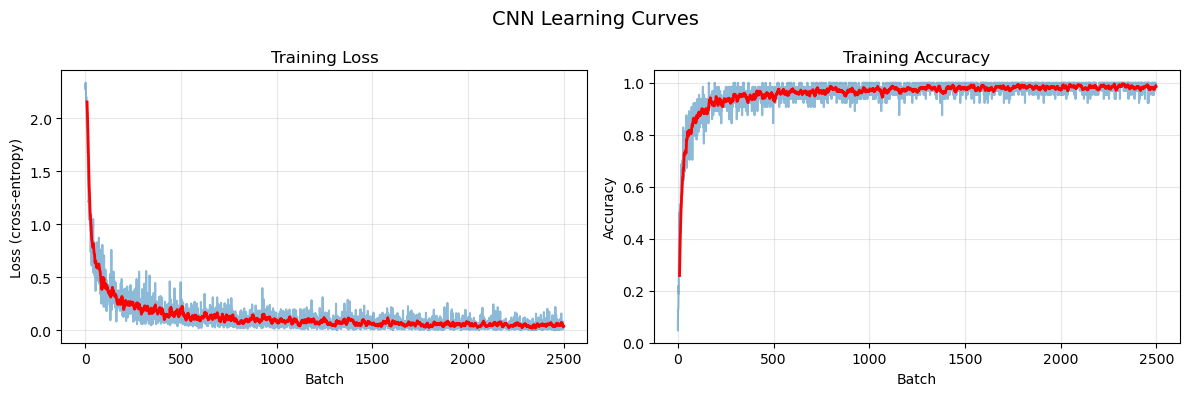

In [ ]:
# === Show learning curves ===

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(model.training_losses, alpha=0.5)
# Moving average
window = 10
moving_avg = np.convolve(model.training_losses, np.ones(window)/window, mode='valid')
axes[0].plot(range(window-1, len(model.training_losses)), moving_avg, 'r-', linewidth=2)
axes[0].set_xlabel('Batch')
axes[0].set_ylabel('Loss (cross-entropy)')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(model.training_accs, alpha=0.5)
moving_avg_acc = np.convolve(model.training_accs, np.ones(window)/window, mode='valid')
axes[1].plot(range(window-1, len(model.training_accs)), moving_avg_acc, 'r-', linewidth=2)
axes[1].set_xlabel('Batch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy')
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN Learning Curves', fontsize=14)
plt.tight_layout()
plt.show()

---

## 5. Evaluate the model

In [8]:
# === Evaluate on test data ===

model.eval()
all_pred = []
all_true = []

with torch.no_grad():
    for batch in test_loader:
        x, y = batch
        logits = model(x)
        pred = torch.argmax(logits, dim=1)
        all_pred.extend(pred.cpu().numpy())
        all_true.extend(y.cpu().numpy())

all_pred = np.array(all_pred)
all_true = np.array(all_true)

# Classification report
print("📊 Classification Report:")
print("="*60)
print(classification_report(all_true, all_pred,
                            target_names=[f'Digit {i}' for i in range(10)]))

📊 Classification Report:
              precision    recall  f1-score   support

     Digit 0       0.99      0.99      0.99       393
     Digit 1       0.99      0.99      0.99       448
     Digit 2       0.98      0.98      0.98       408
     Digit 3       0.99      0.99      0.99       412
     Digit 4       0.98      0.97      0.98       366
     Digit 5       0.99      0.98      0.98       365
     Digit 6       0.98      0.99      0.99       399
     Digit 7       0.98      0.99      0.98       431
     Digit 8       0.98      0.98      0.98       382
     Digit 9       0.97      0.97      0.97       396

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000



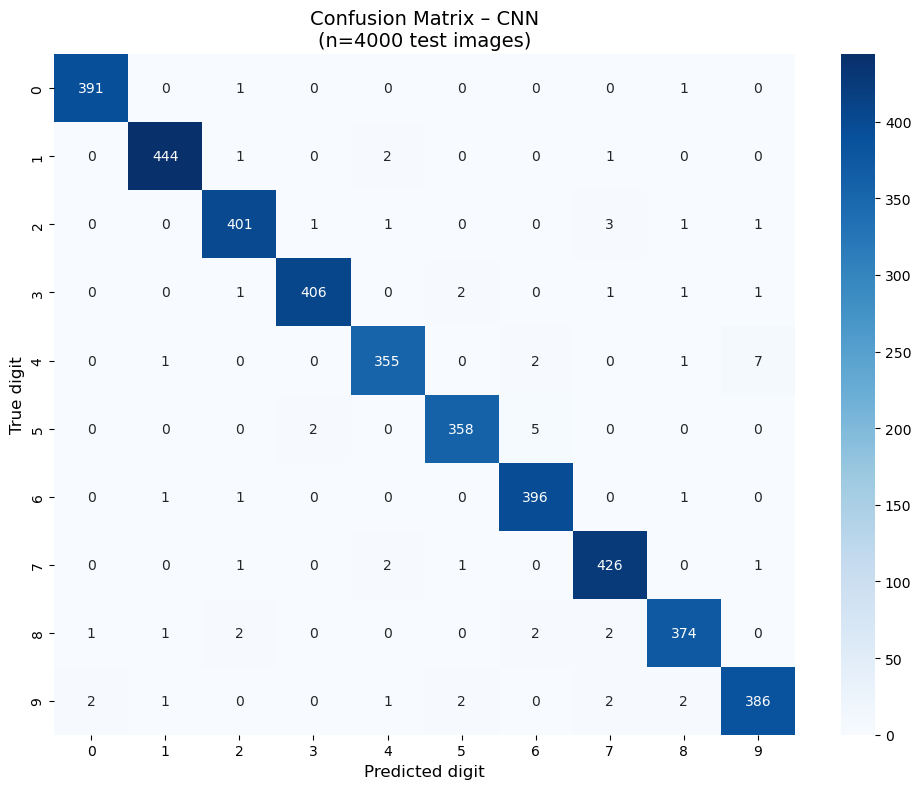


📊 CNN Results:
   Accuracy:   98.4%
   Error rate: 1.6%


In [9]:
# === Confusion matrix ===

plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_true, all_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))

plt.title(f'Confusion Matrix – CNN\n(n={len(all_true)} test images)', fontsize=14)
plt.xlabel('Predicted digit', fontsize=12)
plt.ylabel('True digit', fontsize=12)
plt.tight_layout()
plt.show()

# Summary
accuracy = accuracy_score(all_true, all_pred)
print(f"\n📊 CNN Results:")
print(f"   Accuracy:   {accuracy:.1%}")
print(f"   Error rate: {1-accuracy:.1%}")

---

## 6. Comparison of all three methods

### Results on MNIST (20,000 images)

📊 Model Comparison:
        Model  Accuracy Parameters Spatial structure GPU recommended
Random Forest   0.95000          -                No              No
MLP (256,128)   0.97000     84,060                No              No
          CNN   0.98425  1,199,882               Yes             Yes


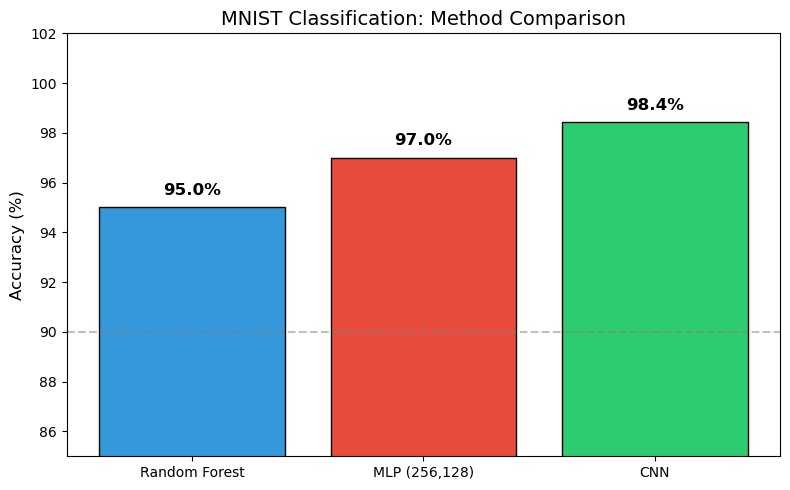

In [10]:
# === Model comparison ===

# Typical results (may vary slightly)
results = {
    'Model': ['Random Forest', 'MLP (256,128)', 'CNN'],
    'Accuracy': [0.95, 0.97, accuracy],
    'Parameters': ['-', '84,060', '1,199,882'],
    'Spatial structure': ['No', 'No', 'Yes'],
    'GPU recommended': ['No', 'No', 'Yes']
}

df_comparison = pd.DataFrame(results)
print("📊 Model Comparison:")
print("="*70)
print(df_comparison.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = ax.bar(results['Model'], [x*100 for x in results['Accuracy']], 
              color=colors, edgecolor='black')

# Add percentage above bars
for bar, acc in zip(bars, results['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1%}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('MNIST Classification: Method Comparison', fontsize=14)
ax.set_ylim(85, 102)
ax.axhline(y=90, color='gray', linestyle='--', alpha=0.5, label='90% threshold')
plt.tight_layout()
plt.show()

### ✅ Check Your Understanding: Model Comparison

**Q1:** CNN has ~99% accuracy vs MLP's ~97%. Is this 2% improvement significant?

<details>
<summary>Click for answer</summary>

**Answer:** It depends on the application!

- **MNIST:** 2% of 10,000 test images = 200 fewer errors. Nice but not critical.
- **Medical diagnosis:** 2% fewer false negatives could mean 200 patients with earlier cancer detection.
- **Autonomous vehicles:** 2% fewer misclassifications could prevent accidents.

The significance depends on:
1. **Dataset size** - larger datasets make small improvements meaningful
2. **Error cost** - high-stakes applications value every improvement
3. **Baseline performance** - going 97%→99% is harder than 50%→52%
</details>

**Q2:** When might you choose MLP over CNN for image classification?

<details>
<summary>Click for answer</summary>

**Answer:**

**Choose MLP when:**
- Very small dataset (<1000 images) - CNN might overfit
- Images have no spatial structure (e.g., spectral data rearranged as image)
- Computational resources are extremely limited
- Interpretability is more important than accuracy

**Choose CNN when:**
- Spatial structure matters (most real images)
- Dataset is large enough (thousands of images)
- State-of-the-art accuracy is needed
- You can use transfer learning from pre-trained models
</details>

**Q3:** Why does CNN perform better than MLP on images?

<details>
<summary>Click for answer</summary>

**Answer:** Three key advantages:

1. **Local connectivity:** Each neuron only sees a small patch, not all 784 pixels
2. **Weight sharing:** Same filter applied everywhere → translation invariance
3. **Hierarchical features:** Layer 1 learns edges → Layer 2 combines into shapes → Layer 3 recognizes objects

Medical analogy: A pathologist doesn't analyze each cell independently - they look at local patterns (cell clusters, tissue organization) to make diagnoses.
</details>

> 💡 **Key Insight:** The best model depends on your data, computational budget, and application requirements. There's no universal "best" algorithm.

### Important: The role of data size for CNN

#### Why CNN sometimes performs worse than MLP with limited data

With **5,000 images**, CNN can actually perform *worse* than MLP. Here's the explanation:

```
┌─────────────────────────────────────────────────────────────────┐
│  Model           Parameters   Data per parameter                │
├─────────────────────────────────────────────────────────────────┤
│  Random Forest   -            Trees, not parameters             │
│  MLP             ~84,000      5000/84000 = 0.06 images/param    │
│  CNN             ~1,200,000   5000/1200000 = 0.004 images/param │
└─────────────────────────────────────────────────────────────────┘
```

**CNN has 14× more parameters** but the same data size → higher risk of **overfitting**!

#### Expected effect of data size

```
                    Typical accuracy at different data sizes
┌──────────────┬─────────┬─────────┬──────────┬──────────┬──────────┐
│  Model       │  1,000  │  5,000  │  10,000  │  30,000  │  60,000  │
├──────────────┼─────────┼─────────┼──────────┼──────────┼──────────┤
│ Random Forest│   88%   │   92%   │   93%    │   94%    │   95%    │
│ MLP          │   92%   │   97%   │  97.5%   │   98%    │  98.5%   │
│ CNN          │   85%   │   96%   │   98%    │   99%    │  99.5%   │
└──────────────┴─────────┴─────────┴──────────┴──────────┴──────────┘
```

**Key point**: CNN "crosses" MLP at ~10,000+ images and shows its strength with larger datasets.

#### Other factors affecting CNN performance

| Factor | Description | Solution |
|--------|-------------|----------|
| **Training epochs** | CNN needs more iterations | Increase `max_epochs` |
| **Data augmentation** | Artificially expand the dataset | Rotation, flipping |
| **Image size** | 28×28 is simple for MLP | CNN shines on larger images |
| **Architecture** | Too complex model → overfitting | Simpler network, more dropout |

#### Medical perspective on model selection

| Data size | Recommended model | Reasoning |
|-----------|-------------------|-----------|
| **< 5,000** | MLP or RF | CNN overfits |
| **5,000-20,000** | Can try both | CNN starts to win |
| **> 20,000** | CNN | Clearly best choice for images |
| **Large images** | CNN always | Regardless of data size |

> 💡 **Lesson**: In medical AI with limited data (e.g., rare diseases), simpler models can actually perform better!

---

## 7. Medical discussion: False positives and negatives

### Digit 8 – a "difficult case"

In our experiments, **digit 8** has consistently had the lowest classification accuracy. Let's analyze this from a medical perspective.

In [11]:
# === Analyze digit 8 specifically ===

# Find all cases where true label is 8
idx_8_true = np.where(all_true == 8)[0]
pred_for_8 = all_pred[idx_8_true]

# Find all cases where prediction is 8
idx_8_pred = np.where(all_pred == 8)[0]
true_for_8_pred = all_true[idx_8_pred]

print("📊 Analysis of digit 8:")
print("="*50)
print(f"\n🎯 True 8s in test set: {len(idx_8_true)}")
print(f"   Correctly classified as 8: {np.sum(pred_for_8 == 8)}")
print(f"   Misclassified (false negative): {np.sum(pred_for_8 != 8)}")

# What were 8s misclassified as?
misclassified_as = pred_for_8[pred_for_8 != 8]
if len(misclassified_as) > 0:
    print(f"\n   Misclassified as: {dict(zip(*np.unique(misclassified_as, return_counts=True)))}")

print(f"\n🔍 Predictions as 8: {len(idx_8_pred)}")
print(f"   Actually 8 (true positive): {np.sum(true_for_8_pred == 8)}")
print(f"   Not 8 (false positive): {np.sum(true_for_8_pred != 8)}")

# Calculate metrics
TP = np.sum((all_true == 8) & (all_pred == 8))
FN = np.sum((all_true == 8) & (all_pred != 8))
FP = np.sum((all_true != 8) & (all_pred == 8))
TN = np.sum((all_true != 8) & (all_pred != 8))

sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
PPV = TP / (TP + FP) if (TP + FP) > 0 else 0  # Positive predictive value

print(f"\n📈 Diagnostic metrics for digit 8:")
print(f"   Sensitivity (recall): {sensitivity:.1%}")
print(f"   Specificity:          {specificity:.1%}")
print(f"   PPV (precision):      {PPV:.1%}")

📊 Analysis of digit 8:

🎯 True 8s in test set: 382
   Correctly classified as 8: 374
   Misclassified (false negative): 8

   Misclassified as: {np.int64(0): np.int64(1), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(6): np.int64(2), np.int64(7): np.int64(2)}

🔍 Predictions as 8: 381
   Actually 8 (true positive): 374
   Not 8 (false positive): 7

📈 Diagnostic metrics for digit 8:
   Sensitivity (recall): 97.9%
   Specificity:          99.8%
   PPV (precision):      98.2%


### Medical analogy: What if "8" was a critical diagnosis?

Imagine that digit **8** represents a **serious diagnosis** (e.g., cancer), while other digits are benign conditions.

| Outcome | MNIST analogy | Medical consequence |
|---------|---------------|---------------------|
| **True positive** | 8 → 8 | Correct cancer diagnosis → Treatment starts |
| **False negative** | 8 → 0,3,5... | Cancer missed! → Delayed treatment |
| **False positive** | 0,3,5 → 8 | False alarm → Unnecessary worry/biopsy |
| **True negative** | Not 8 → Not 8 | Correct clearance |

### Why do models fail on 8?

```
     ┌───┐      ┌───┐      ┌───┐      ┌───┐
     │ 0 │      │ 3 │      │ 5 │      │ 8 │
     │ ○ │      │ ∋ │      │ S │      │ 8 │
     └───┘      └───┘      └───┘      └───┘
     Closed     Open       Curves     Closed
     circle     curves     and lines  double
```

Digit **8** shares visual properties with:
- **0**: Closed shape
- **3**: Curves on the right side
- **5**: S-like curves
- **6/9**: Circles

### Model choice: Sensitivity vs specificity

In medical diagnostics, we must choose between:

| Strategy | Focus | Consequence |
|----------|-------|-------------|
| **High sensitivity** | Catch all sick patients | More false positives (unnecessary tests) |
| **High specificity** | Avoid false alarms | Risk of missing cases |

#### Example: Screening vs diagnosis

```
SCREENING                      DIAGNOSIS
(first line)                   (confirmation)
┌─────────────────┐           ┌─────────────────┐
│ High sensitivity│           │ High specificity│
│ (catch all)     │     →     │ (confirm)       │
│                 │           │                 │
│ Random Forest?  │           │ CNN!            │
└─────────────────┘           └─────────────────┘
```

### Conclusions from our experiments

| Model | Best use case |
|-------|---------------|
| **Random Forest** | Quick baseline, interpretable, limited data |
| **MLP** | Better accuracy, non-image data |
| **CNN** | Image data, highest accuracy, GPU recommended |

In [12]:
# === Save the model ===

model_file = data_folder / 'mnist_cnn_model.pt'
torch.save(model.state_dict(), model_file)

print(f"✅ CNN model saved to: {model_file}")
print(f"   File size: {model_file.stat().st_size / 1e6:.2f} MB")

✅ CNN model saved to: mnist_data/mnist_cnn_model.pt
   File size: 4.80 MB


---

## 📚 Glossary of Key Terms

| Term | Definition | In This Notebook |
|------|------------|------------------|
| **Batch size** | Number of samples processed together | 64 images per batch |
| **CNN** | Convolutional Neural Network | Our main model |
| **Conv2d** | 2D convolution layer | Detects spatial patterns |
| **Cross-entropy** | Loss function for classification | Measures prediction error |
| **DataLoader** | PyTorch utility for batching data | Handles shuffling, batching |
| **Dropout** | Regularization by randomly dropping neurons | 0.25 after conv, 0.5 after FC |
| **Epoch** | One complete pass through training data | We trained for 10 epochs |
| **Feature map** | Output of a convolutional layer | Shows where patterns were detected |
| **Flatten** | Reshape 3D tensors to 1D | Before fully connected layers |
| **Kernel/Filter** | Small weight matrix for convolution | 3×3 in our model |
| **Lightning** | High-level PyTorch framework | Simplifies training code |
| **Logits** | Raw network outputs before softmax | 10 values per image |
| **MaxPool** | Take maximum in each window | Downsamples, adds invariance |
| **ReLU** | Rectified Linear Unit: max(0, x) | Activation function |
| **Stride** | Step size when sliding the kernel | 1 for conv, 2 for pool |
| **Tensor** | N-dimensional array in PyTorch | [batch, channels, height, width] |
| **Transfer learning** | Using pre-trained model for new task | Common in medical imaging |

---

## Summary: Learning journey complete!

### What we have learned

| Notebook | Model | Key insight |
|----------|-------|-------------|
| **A4** | Random Forest | Baseline, interpretable, fast |
| **A5** | MLP | Neural nets learn representations |
| **A6** | CNN | Spatial structure gives best results |

### Main findings

1. **CNN > MLP > RF** for image classification
2. **Digit 8** is consistently the hardest to classify
3. **Spatial structure** is the key to CNN's success
4. **Model choice** depends on the use case

### Clinical relevance

```
┌─────────────────────────────────────────────────────────────┐
│  In medical AI:                                             │
│                                                             │
│  • False negatives = Missed diagnosis → SERIOUS             │
│  • False positives = Unnecessary follow-up → Costly         │
│                                                             │
│  The balance between sensitivity and specificity            │
│  must be adapted to the clinical context!                   │
└─────────────────────────────────────────────────────────────┘
```

> 💡 **Take-away**: AI tools are support for, not replacement of, clinical judgment!

---

## 🎯 Exercises

### Exercise 1: Analyze another class
Repeat the analysis of digit 8, but for digit **4** or **9**. Are they equally difficult to classify?

<details>
<summary>💡 Show hint</summary>

```python
digit = 4  # Change to desired digit
idx_true = np.where(all_true == digit)[0]
pred_for_digit = all_pred[idx_true]
recall = np.sum(pred_for_digit == digit) / len(idx_true)
print(f"Recall for digit {digit}: {recall:.1%}")
```

</details>

### Exercise 2: Adjust the threshold
Instead of `argmax`, use probabilities and adjust the threshold to increase sensitivity for digit 8.

<details>
<summary>💡 Show hint</summary>

```python
# Get probabilities
model.eval()
with torch.no_grad():
    logits = model(X_test_t[:100])
    prob = F.softmax(logits, dim=1)

# Lower threshold for class 8
threshold_8 = 0.3  # Instead of 0.5
pred_8 = prob[:, 8] > threshold_8
```

</details>

### Exercise 3: Visualize CNN filters
Visualize the learned filters in the first convolutional layer.

<details>
<summary>💡 Show solution</summary>

```python
filters = model.conv1.weight.data.cpu().numpy()
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(filters[i, 0], cmap='RdBu')
    ax.axis('off')
plt.suptitle('CNN Filters (First Layer)')
plt.show()
```

</details>

### Summary: PyTorch vs Lightning

| Aspect | Pure PyTorch | PyTorch Lightning |
|--------|-------------|-------------------|
| **Training loop** | Manual (for-loop) | Automatic (`trainer.fit()`) |
| **Code structure** | Free-form, can get messy | Organized into methods |
| **Logging** | Manual `print()` | Built-in `self.log()` |
| **GPU support** | Manual `.to(device)` | Automatic |
| **Checkpointing** | Manual saving | Built-in |

**When to use what?**
- 🔧 **Pure PyTorch**: To understand what happens, experimentation, simple tasks
- ⚡ **Lightning**: For production code, larger projects, reproducible research

### Platform-specific notes

| Platform | Accelerator | `num_workers` in DataLoader |
|----------|-------------|---------------------------|
| **Apple Silicon** (M1–M4) | MPS (Metal) | Must be `0` due to multiprocessing limitations |
| **NVIDIA GPU** | CUDA | Can be `>0` for parallel loading |
| **CPU** | – | Can be `>0` |

> 💡 **Tip:** PyTorch supports Apple Silicon via **MPS** (Metal Performance Shaders). Lightning detects this automatically!


---

## 📖 Further Reading & Resources

### Deep Learning Fundamentals

| Resource | Description |
|----------|-------------|
| **3Blue1Brown: Neural Networks** | Beautiful visual explanations |
| **Fast.ai Practical Deep Learning** | Hands-on, top-down approach |
| **PyTorch Tutorials** | Official PyTorch documentation and examples |
| **CS231n: CNNs for Visual Recognition** | Stanford's comprehensive CNN course |

### Medical Imaging AI

| Resource | Description |
|----------|-------------|
| **MONAI** | PyTorch-based framework for medical imaging |
| **fastMONAI** | High-level API for medical imaging deep learning |
| **Grand Challenge** | Platform for medical imaging AI competitions |
| **Papers With Code - Medical** | Latest medical imaging papers with code |

### Landmark Papers

| Paper | Contribution |
|-------|--------------|
| **LeNet (1998)** | First successful CNN for digit recognition |
| **AlexNet (2012)** | Sparked the deep learning revolution |
| **VGG (2014)** | Showed deeper is better (with small filters) |
| **ResNet (2015)** | Skip connections enabled very deep networks |
| **U-Net (2015)** | Standard architecture for medical image segmentation |

### Next Steps in Your Learning Journey

| Topic | Why It Matters |
|-------|----------------|
| **Transfer learning** | Use pre-trained models for medical imaging |
| **Data augmentation** | Improve performance with limited data |
| **Semantic segmentation** | Pixel-wise classification (tumor boundaries) |
| **Object detection** | Find and localize abnormalities |
| **Explainable AI** | Understand why the model made a decision |

---

## 🎯 Key Takeaways from the Learning Journey

```
┌─────────────────────────────────────────────────────────────────────────┐
│                    MNIST Classification Journey                          │
├─────────────────┬─────────────────┬─────────────────┬───────────────────┤
│   Method        │   Accuracy      │   Key Insight   │   Best For        │
├─────────────────┼─────────────────┼─────────────────┼───────────────────┤
│ Random Forest   │   ~95%          │ Fixed features  │ Quick baseline    │
│ MLP             │   ~97%          │ Learned features│ Tabular data      │
│ CNN             │   ~99%          │ Spatial aware   │ Images            │
└─────────────────┴─────────────────┴─────────────────┴───────────────────┘
```

**You now understand:**
- ✅ How CNNs exploit spatial structure for image analysis
- ✅ The trade-offs between different ML approaches
- ✅ How to train and evaluate deep learning models
- ✅ The connection between these techniques and medical imaging AI

---

*Congratulations on completing the MNIST classification journey!*

*Next: Apply these concepts to real medical imaging with MONAI and transfer learning.*